<a href="https://colab.research.google.com/github/anastasiapap10/wine-quality-prediction/blob/main/wine_quality_prediction_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wine Quality Prediction

This project explores the relationship between the chemical properties of red wine and its quality score.

The analysis includes exploratory data analysis, visualization, and machine learning models to predict wine quality.

## Technologies
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv ("winequality-red.csv", sep = ";")

In [ ]:
#The first 5 rows:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
#Statistical summary:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [ ]:
#Frequency of the quality of wine:
frequency = df["quality"].value_counts().sort_index()
print(frequency)

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Frequency of quality')

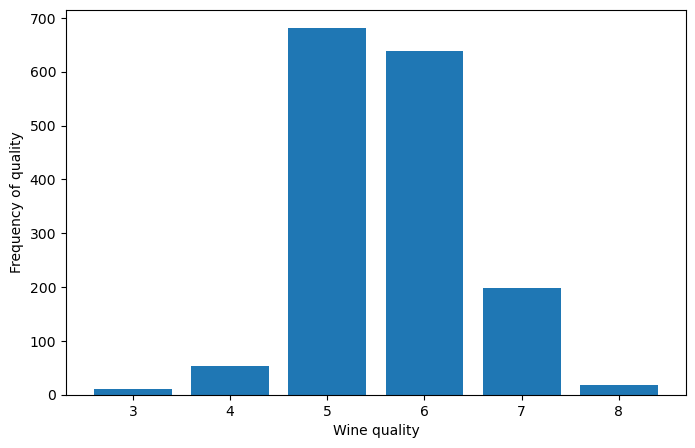

In [ ]:
#Create the bar plot of the frequency of the wine quality:
plt.figure(figsize = (8,5))
plt.bar(frequency.index,frequency.values)
plt.xlabel("Wine quality")
plt.ylabel("Frequency of quality")

Text(0, 0.5, 'quality')

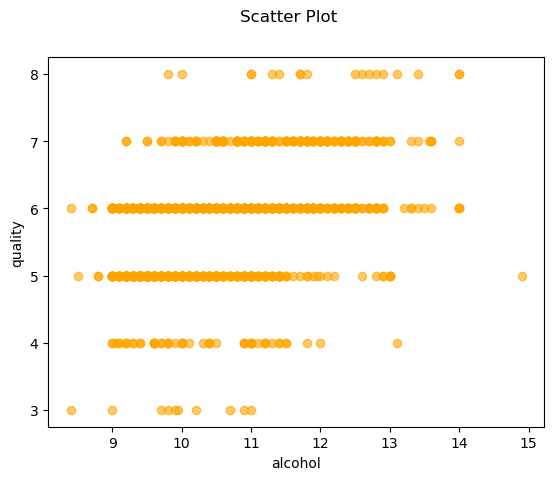

In [ ]:
#Create the scatter plot about the quality of the wine and the alcohol:
plt.scatter(df["alcohol"],df["quality"], color = "orange", alpha = 0.6)
plt.suptitle("Scatter Plot")
plt.xlabel("alcohol")
plt.ylabel("quality")

In [ ]:
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
#Define the values of X and Y for the Linear Regression:
X = df.drop(columns = ["quality"])

In [ ]:
Y = df["quality"]

In [ ]:
#Split the data into training and testing:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

In [ ]:
model = LinearRegression()

In [ ]:
model.fit( X_train, Y_train)

LinearRegression()

In [ ]:
Y_pred_linear = model.predict(X_test)

In [ ]:
mse = mean_squared_error( Y_test, Y_pred_linear)
r2 = r2_score( Y_test, Y_pred_linear)
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R^2 Score: {r2:.4f}")

Mean Squared Error (MSE): 0.3900
R^2 Score: 0.4032


In [ ]:
print("Mean squared error: This means that the difference between the actual and predicted is 39%.")
print("R^2 score: This means that the features explain 40% of the wine quality.")

Mean squared error: This means that the difference between the actual and predicted is 39%.
R^2 score: This means that the features explain 40% of the wine quality.


In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
rf_model = RandomForestRegressor( n_estimators = 100, random_state = 42)

In [ ]:
rf_model.fit(X_train, Y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test)

In [ ]:
forest_mse = mean_squared_error( Y_test, y_pred_rf)
forest_r2 = r2_score( Y_test, y_pred_rf)
print(f"Mean Squared Error (MSE): {forest_mse:.4f}")
print(f"R^2 Score: {forest_r2:.4f}")

Mean Squared Error (MSE): 0.3012
R^2 Score: 0.5390


In [ ]:
#For Phase 4, I created a matrix with the metrics from both Model A and Model B:
comparison = { "Model" : ["Model A", "Model B"],
              "MSE" : [mse, forest_mse],
              "R^2 Score" : [r2, forest_r2]}

In [ ]:
print(pd.DataFrame(comparison))

     Model       MSE  R^2 Score
0  Model A  0.390025   0.403180
1  Model B  0.301238   0.539043


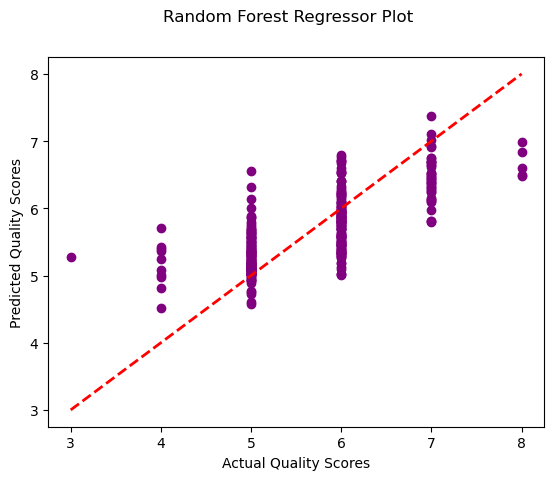

In [ ]:
#Scatter Plot for Random Forest
plt.scatter(Y_test, y_pred_rf, color = "purple")
plt.xlabel("Actual Quality Scores")
plt.ylabel("Predicted Quality Scores")
plt.suptitle("Random Forest Regressor Plot")
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2)

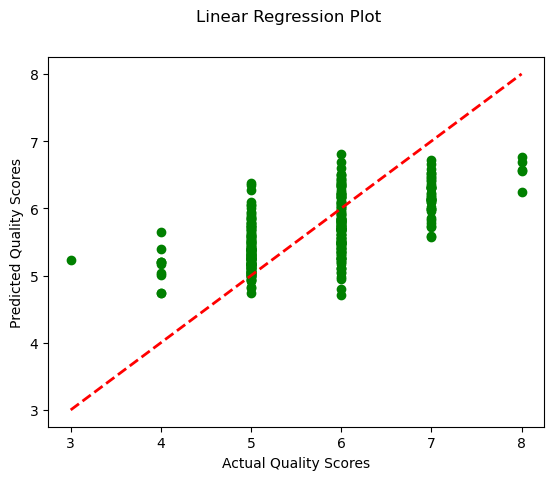

In [ ]:
#Scatter Plot for Linear Regression
plt.scatter(Y_test, Y_pred_linear, color = "green")
plt.xlabel("Actual Quality Scores")
plt.ylabel("Predicted Quality Scores")
plt.suptitle("Linear Regression Plot")
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2)

In [ ]:
print("The Random Forest achieved a higher R^2 score (40%) than the Linear Regression by 0.13.")
print("The Random Forest's lower MSE can demonstrate better the data because the predictions are closer to the actual data.")
print("A non-linear model is better suited to predict a subjective score because wine quality depends on many chemical factors with non-linear",
"relationships where only a model like Random Forest can actual capture them.")
print("A practical next step to improve the Random Forest would be by using pivot tables to understand more how the data works and find patterns between",
"chemical attributes. For example, using a correlation heatmap, we could see which of the attributes has the strongest relationship with the wine quality.",
"After that, we could use these atrributes to create a pivot table.")

The Random Forest achieved a higher R^2 score (40%) than the Linear Regression by 0.13.
The Random Forest's lower MSE can demonstrate better the data because the predictions are closer to the actual data.
A non-linear model is better suited to predict a subjective score because wine quality depends on many chemical factors with non-linear relationships where only a model like Random Forest can actual capture them.
A practical next step to improve the Random Forest would be by using pivot tables to understand more how the data works and find patterns between chemical attributes. For example, using a correlation heatmap, we could see which of the attributes has the strongest relationship with the wine quality. After that, we could use these atrributes to create a pivot table.
